2025Q1中国移动互联网发展总览-1
https://report.iresearch.cn/report_pdf.aspx?id=4719

In [1]:
import matplotlib.pyplot as plt
# 设置中文字体支持
import matplotlib.font_manager as fm
# 备选中文字体列表
chinese_fonts = [
    "SimHei",           # Windows
    "Heiti TC",         # macOS
    "WenQuanYi Micro Hei",  # Linux
    "Microsoft YaHei",  # 微软雅黑
    "Arial Unicode MS", # 备选
]

# 获取系统可用字体
available_fonts = {f.name for f in fm.fontManager.ttflist}

# 查找第一个可用的中文字体
for font in chinese_fonts:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

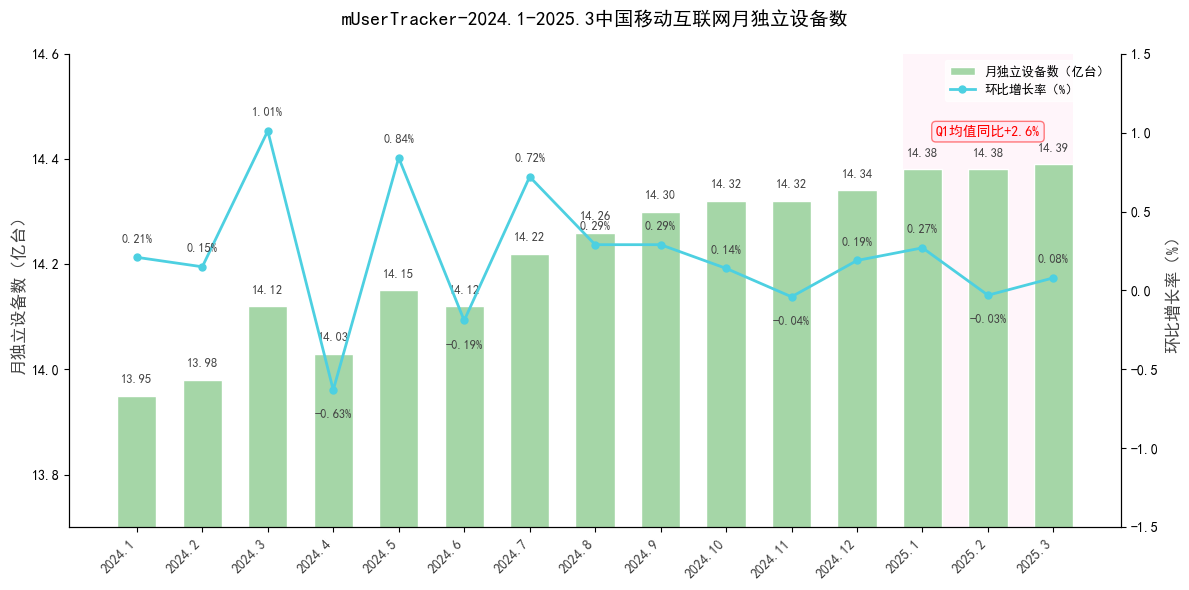

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
months = [
    "2024.1", "2024.2", "2024.3", "2024.4", "2024.5", 
    "2024.6", "2024.7", "2024.8", "2024.9", "2024.10", 
    "2024.11", "2024.12", "2025.1", "2025.2", "2025.3"
]
device_counts = [13.95, 13.98, 14.12, 14.03, 14.15, 14.12, 14.22, 14.26, 14.30, 14.32, 14.32, 14.34, 14.38, 14.38, 14.39]
growth_rates = [0.21, 0.15, 1.01, -0.63, 0.84, -0.19, 0.72, 0.29, 0.29, 0.14, -0.04, 0.19, 0.27, -0.03, 0.08]

# 配色
bar_color = "#a5d6a7"
line_color = "#4dd0e1"
highlight_color = "#ffe0f0"
text_color = "#424242"

# 创建图表
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

x = np.arange(len(months))

# 柱状图
bars = ax1.bar(
    x, device_counts, color=bar_color, width=0.6,
    edgecolor="white", linewidth=1,
    label="月独立设备数（亿台）"
)

# 折线图
ax2.plot(
    x, growth_rates, color=line_color, marker="o",
    linewidth=2, markersize=5, label="环比增长率（%）"
)

# 坐标轴范围
ax1.set_ylim(13.7, 14.6)
ax2.set_ylim(-1.5, 1.5)

# 柱状图文字标注（改为柱顶上方）
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.02,
        f"{height:.2f}",
        ha="center", va="bottom",
        fontsize=9, color=text_color,
        fontweight="bold"
    )

# 折线图文字标注（避免重叠）
for i, val in enumerate(growth_rates):
    y_offset = 0.08 if val >= 0 else -0.12
    va = "bottom" if val >= 0 else "top"
    ax2.text(
        i, val + y_offset,
        f"{val:.2f}%",
        ha="center", va=va,
        fontsize=9, color=text_color,
        fontweight="bold"
    )

# Q1 高亮区
q1_start = months.index("2025.1")
q1_end = months.index("2025.3")
ax1.axvspan(q1_start - 0.3, q1_end + 0.3, facecolor=highlight_color, alpha=0.3, zorder=0)
ax1.text(
    (q1_start + q1_end) / 2, max(device_counts) + 0.05,
    "Q1均值同比+2.6%", ha="center", va="bottom",
    fontsize=10, color="red", fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.3", fc=highlight_color, ec="red", alpha=0.5)
)

# X轴
ax1.set_xticks(x)
ax1.set_xticklabels(months, rotation=45, ha="right", fontsize=10, color=text_color)

# Y轴标签
ax1.set_ylabel("月独立设备数（亿台）", fontsize=12, color=text_color)
ax2.set_ylabel("环比增长率（%）", fontsize=12, color=text_color)

# 图例
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=9, frameon=True, facecolor="white", edgecolor="white")

# 去除边框
ax1.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)

# 标题
ax1.set_title(
    "mUserTracker-2024.1-2025.3中国移动互联网月独立设备数",
    fontsize=14, fontweight="bold", pad=20
)

plt.tight_layout()
plt.show()


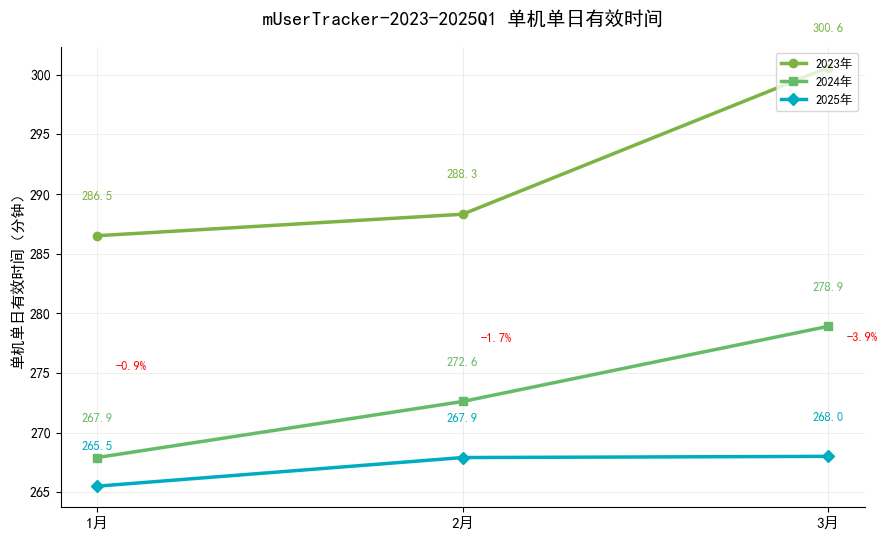

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# -------------------- 数据定义 --------------------
months = ["1月", "2月", "3月"]
years = ["2023年", "2024年", "2025年"]

# 数据：[2023, 2024, 2025]（分钟）
data = np.array([
    [286.5, 267.9, 265.5],  # 1月
    [288.3, 272.6, 267.9],  # 2月
    [300.6, 278.9, 268.0],  # 3月
])

# 色彩风格升级
colors = ["#7CB342", "#66BB6A", "#00ACC1"]  # 对应2023/2024/2025
markers = ["o", "s", "D"]

# -------------------- 创建画布 --------------------
fig, ax = plt.subplots(figsize=(9, 5.5))

# -------------------- 绘制多条折线 --------------------
x = np.arange(len(months))
for i in range(len(years)):
    y = data[:, i]
    ax.plot(
        x, y, marker=markers[i], linewidth=2.5, 
        label=years[i], color=colors[i]
    )
    # 添加数据标注
    for j, val in enumerate(y):
        ax.text(
            x[j], val + 3,
            f"{val}", ha='center', fontsize=9,
            color=colors[i], fontweight='bold'
        )

# -------------------- 同比增长率标注（2024→2025） --------------------
for i in range(len(months)):
    rate = data[i][2] - data[i][1]
    rate_pct = round((rate / data[i][1]) * 100, 1)
    color = "red" if rate_pct < 0 else "green"
    ax.text(
        x[i] + 0.05, data[i][2] + 10,
        f"{rate_pct:+}%", color=color,
        fontsize=9, ha="left", va="center", fontweight="bold"
    )

# -------------------- 美化图表 --------------------
ax.set_xticks(x)
ax.set_xticklabels(months, fontsize=11)
ax.set_ylabel("单机单日有效时间（分钟）", fontsize=11)
ax.set_title("mUserTracker-2023-2025Q1 单机单日有效时间", fontsize=14, fontweight="bold", pad=15)

# 网格线
ax.grid(alpha=0.2)

# 图例
ax.legend(loc="upper right", fontsize=9, frameon=True)

# 去除多余边框
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()


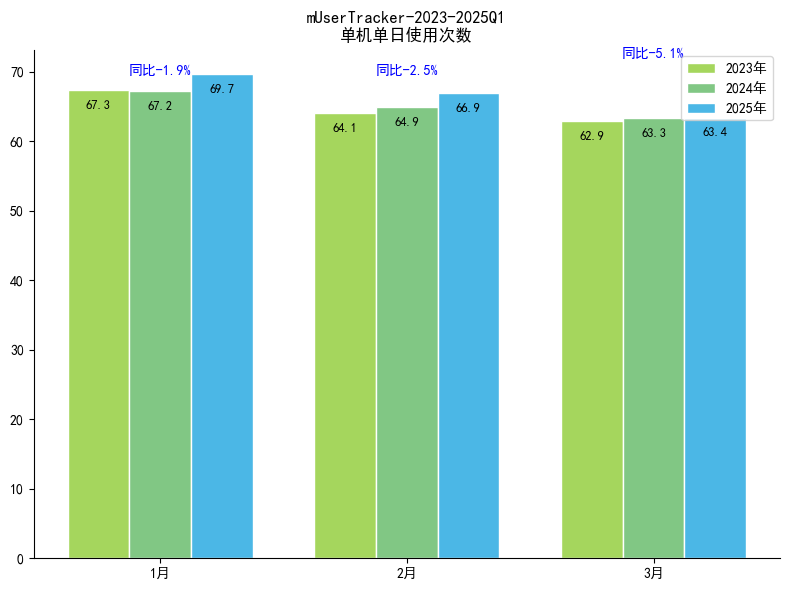

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# 数据定义
months = ["1月", "2月", "3月"]
years = ["2023年", "2024年", "2025年"]
data = [
    [67.3, 64.1, 62.9],
    [67.2, 64.9, 63.3],
    [69.7, 66.9, 63.4]
]
growth_rates = ["同比-1.9%", "同比-2.5%", "同比-5.1%"]
colors = ["#a5d65d", "#81c784", "#4bb7e6"]  # 匹配图表颜色

# 创建画布
fig, ax = plt.subplots(figsize=(8, 6))

# 绘制分组柱状图
x = np.arange(len(months))
bar_width = 0.25
for i in range(3):
    ax.bar(x + i * bar_width, data[i], width=bar_width, color=colors[i], label=years[i], edgecolor='white')
    # 添加数据标注
    for j, val in enumerate(data[i]):
        ax.text(x[j] + i * bar_width, val -3, f'{val}', ha='center', va='bottom', fontsize=9)

# 添加同比注释
for i in range(3):
    ax.text(x[i] + 1 * bar_width, max(data[i]) + 2, growth_rates[i], ha='center', va='bottom', fontsize=10, color='blue')

# 美化设置
ax.set_title("mUserTracker-2023-2025Q1\n单机单日使用次数", fontsize=12, fontweight='bold')
ax.set_xticks(x + bar_width)
ax.set_xticklabels(months)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()